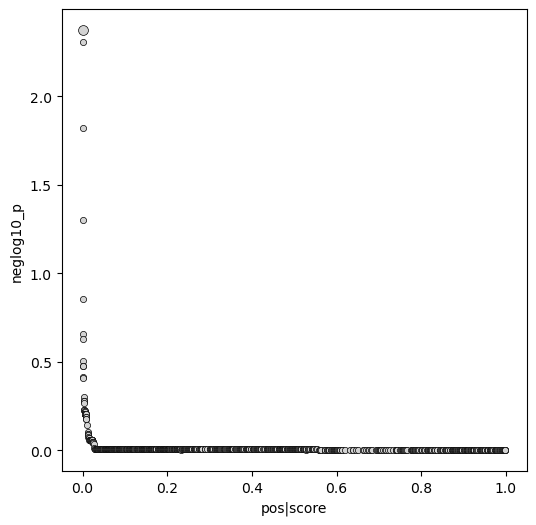

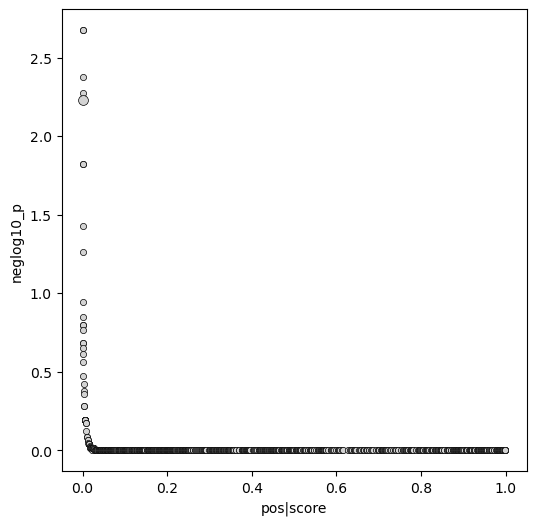

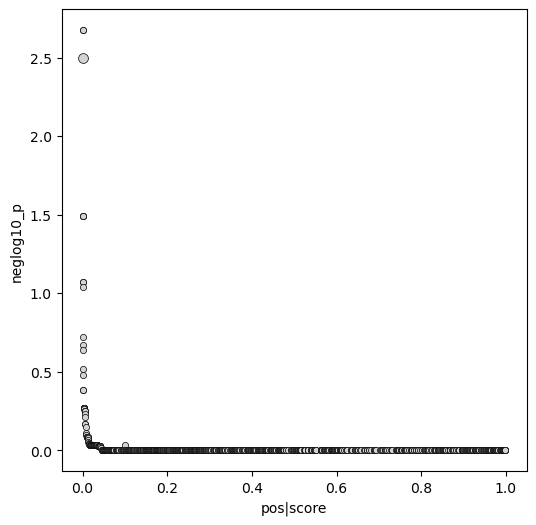

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

dirs = ["/home/wkkongaa/data/notebooks/260416_novaseq99/analysis/MAGeCK_output/599/599.gene_summary.txt", 
        "/home/wkkongaa/data/notebooks/260416_novaseq99/analysis/MAGeCK_output/600/600.gene_summary.txt", 
        "/home/wkkongaa/data/notebooks/260416_novaseq99/analysis/MAGeCK_output/WT/WT.gene_summary.txt"]

samples = ["miR494_7merSupp_MHCC97-L", "miR494_7mer_MHCC97-L", "wildtype_MHCC97-L"]

for dir, sample in zip(dirs, samples):
    df = pd.read_table(dir).sort_values(by="pos|rank")[["id", "pos|fdr", "pos|score"]]
    df["neglog10_p"] = -np.log10(df["pos|fdr"])
    plt.figure(figsize=(6, 6))
    sns.scatterplot(
                    x=df["pos|score"], 
                    y=df["neglog10_p"], 
                    color="lightgrey", 
                    edgecolor="black", 
                    linewidth=0.5, 
                    s=20
                    )
    df = df[df["id"].isin(["RPLP0"])]
    sns.scatterplot(
                    x=df["pos|score"], 
                    y=df["neglog10_p"], 
                    color="lightgrey", 
                    edgecolor="black", 
                    linewidth=0.5, 
                    s=50
                    )
    plt.show()

In [15]:

# ============================================================
# MAGeCK RRA Visualization — Jupyter Notebook Code
# ============================================================
# For shRNA/CRISPR screen results from `mageck rra` or `mageck test`
# 
# Sections:
#   1. Load MAGeCK output (or generate simulated demo data)
#   2. Process: combine pos/neg arms, compute significance
#   3. Volcano plot — combined arms (MAGeCKFlute VolcanoView style)
#   4. Volcano plot — two-panel (pos and neg separately)
#   5. Rank plot (MAGeCKFlute RankView style)
#   6. Top-hits bar plot (published HCC screen style)
#   7. sgRNA-level view for specific genes
#   8. Enrichment dot plot (optional, if pathway results available)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')


# Phylo color palette
COLOR_NS   = '#BDBDBD'   # non-significant
COLOR_POS  = '#0279EE'   # positive selection (resistance)
COLOR_NEG  = '#FF9400'   # negative selection (sensitivity)
COLOR_HL   = '#FD9BED'   # highlighted hit


# ---- Adjustable parameters ----
FDR_THRESHOLD   = 0.05
LFC_THRESHOLD   = 0.5
HIGHLIGHT_GENES = ['RPLP0']
TOP_N_LABEL     = 10

print("Styling and parameters loaded.")
print(f"  FDR threshold: {FDR_THRESHOLD}")
print(f"  LFC threshold: {LFC_THRESHOLD}")
print(f"  Highlight genes: {HIGHLIGHT_GENES}")


Styling and parameters loaded.
  FDR threshold: 0.05
  LFC threshold: 0.5
  Highlight genes: ['RPLP0']


In [32]:
# ============================================================
# Cell 2: Load MAGeCK output
# ============================================================

def load_mageck_rra(filepath):
    df = pd.read_csv(filepath, sep='\t')
    # Normalize column names (MAGeCK uses 'pos|lfc', 'pos|fdr', etc.)
    col_map = {}
    for c in df.columns:
        cl = c.lower().replace(' ', '')
        if cl == 'pos|lfc':  col_map[c] = 'pos_lfc'
        elif cl == 'pos|fdr': col_map[c] = 'pos_fdr'
        elif cl == 'neg|lfc': col_map[c] = 'neg_lfc'
        elif cl == 'neg|fdr': col_map[c] = 'neg_fdr'
    df = df.rename(columns=col_map)
    return df
df = load_mageck_rra("/home/wkkongaa/data/notebooks/260416_novaseq99/analysis/MAGeCK_output/WT/WT.gene_summary.txt")


print(f"Loaded {len(df)} genes")
print(f"  Significant pos hits (FDR<{FDR_THRESHOLD}, LFC>{LFC_THRESHOLD}): "
      f"{((df['pos_fdr'] < FDR_THRESHOLD) & (df['pos_lfc'] > LFC_THRESHOLD)).sum()}")
print(f"  Significant neg hits (FDR<{FDR_THRESHOLD}, LFC<-{LFC_THRESHOLD}): "
      f"{((df['neg_fdr'] < FDR_THRESHOLD) & (df['neg_lfc'] < -LFC_THRESHOLD)).sum()}")


Loaded 861 genes
  Significant pos hits (FDR<0.05, LFC>0.5): 6
  Significant neg hits (FDR<0.05, LFC<-0.5): 1


In [33]:

# ============================================================
# Cell 3: Process — combine pos/neg arms
# ============================================================
# MAGeCKFlute approach: 
#   combined_lfc = pos|lfc if pos|fdr <= neg|fdr, else neg|lfc
#   combined_fdr = min(pos|fdr, neg|fdr)

df['combined_lfc'] = np.where(df['pos_fdr'] <= df['neg_fdr'],
                               df['pos_lfc'], df['neg_lfc'])
df['combined_fdr'] = np.minimum(df['pos_fdr'], df['neg_fdr'])
df['neg_log10_fdr'] = -np.log10(df['combined_fdr'] + 1e-10)

# Significance flags
df['sig_pos'] = (df['pos_fdr'] < FDR_THRESHOLD) & (df['pos_lfc'] > LFC_THRESHOLD)
df['sig_neg'] = (df['neg_fdr'] < FDR_THRESHOLD) & (df['neg_lfc'] < -LFC_THRESHOLD)
df['sig_combined_pos'] = (df['combined_fdr'] < FDR_THRESHOLD) & (df['combined_lfc'] > LFC_THRESHOLD)
df['sig_combined_neg'] = (df['combined_fdr'] < FDR_THRESHOLD) & (df['combined_lfc'] < -LFC_THRESHOLD)

print("Combined columns added:")
print(f"  combined_lfc range: [{df['combined_lfc'].min():.2f}, {df['combined_lfc'].max():.2f}]")
print(f"  combined_fdr range: [{df['combined_fdr'].min():.2e}, {df['combined_fdr'].max():.2e}]")
print(f"\nRPLP0 row:")
print(df[df['id'] == 'RPLP0'][['id', 'pos_lfc', 'pos_fdr', 'combined_lfc', 'combined_fdr']].to_string(index=False))



Combined columns added:
  combined_lfc range: [-0.95, 1.41]
  combined_fdr range: [2.12e-03, 9.99e-01]

RPLP0 row:
   id  pos_lfc  pos_fdr  combined_lfc  combined_fdr
RPLP0   1.4061 0.003178        1.4061      0.003178


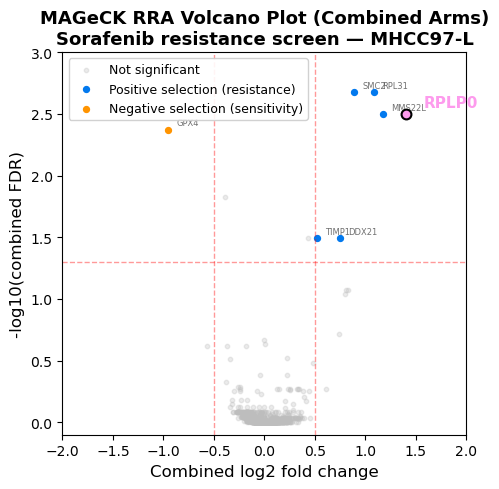

Saved: viz_combined_volcano.png / .svg


In [34]:

# ============================================================
# Cell 4: Volcano plot — combined arms (MAGeCKFlute VolcanoView style)
# ============================================================
# Shows both positive selection (resistance) and negative selection (sensitivity)
# in a single plot. This is the recommended primary visualization.

fig, ax = plt.subplots(figsize=(5, 5))

not_sig = ~df['sig_combined_pos'] & ~df['sig_combined_neg']

ax.scatter(df.loc[not_sig, 'combined_lfc'], df.loc[not_sig, 'neg_log10_fdr'],
           c=COLOR_NS, s=10, alpha=0.3, label='Not significant')
ax.scatter(df.loc[df['sig_combined_pos'], 'combined_lfc'], 
           df.loc[df['sig_combined_pos'], 'neg_log10_fdr'],
           c=COLOR_POS, s=18, alpha=1, label='Positive selection (resistance)')
ax.scatter(df.loc[df['sig_combined_neg'], 'combined_lfc'], 
           df.loc[df['sig_combined_neg'], 'neg_log10_fdr'],
           c=COLOR_NEG, s=18, alpha=1, label='Negative selection (sensitivity)')

# Highlight specific genes
for gene, color in zip(HIGHLIGHT_GENES, [COLOR_HL]):
    row = df[df['id'] == gene]
    if len(row) > 0:
        ax.scatter(row['combined_lfc'], row['neg_log10_fdr'],
                   c=color, s=50, edgecolors='black', linewidth=1.5, zorder=5)
        ax.annotate(gene, (row['combined_lfc'].values[0], row['neg_log10_fdr'].values[0]),
                    textcoords="offset points", xytext=(12, 5),
                    fontsize=11, fontweight='bold', color=color)

# Auto-label top hits (excluding already-highlighted)
top_pos = df[df['sig_combined_pos']].nlargest(TOP_N_LABEL, 'combined_lfc')
top_neg = df[df['sig_combined_neg']].nsmallest(TOP_N_LABEL, 'combined_lfc')
for _, row in pd.concat([top_pos, top_neg]).iterrows():
    if row['id'] not in HIGHLIGHT_GENES:
        ax.annotate(row['id'], (row['combined_lfc'], row['neg_log10_fdr']),
                    textcoords="offset points", xytext=(6, 3),
                    fontsize=6, alpha=0.7, color='#333333')

# Threshold lines
ax.axhline(-np.log10(FDR_THRESHOLD), color='red', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(LFC_THRESHOLD, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(-LFC_THRESHOLD, color='red', linestyle='--', alpha=0.4, linewidth=1)

ax.set_xlabel('Combined log2 fold change', fontsize=12)
ax.set_ylabel('-log10(combined FDR)', fontsize=12)
ax.set_title('MAGeCK RRA Volcano Plot (Combined Arms)\nSorafenib resistance screen — MHCC97-L',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.set_xlim(-2, 2)
ax.set_ylim(-0.1, 3)

plt.tight_layout()
plt.savefig('/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_figure/figures/main_text/MAGeCK_volcano_WT.pdf')
plt.show()
print("Saved: viz_combined_volcano.png / .svg")


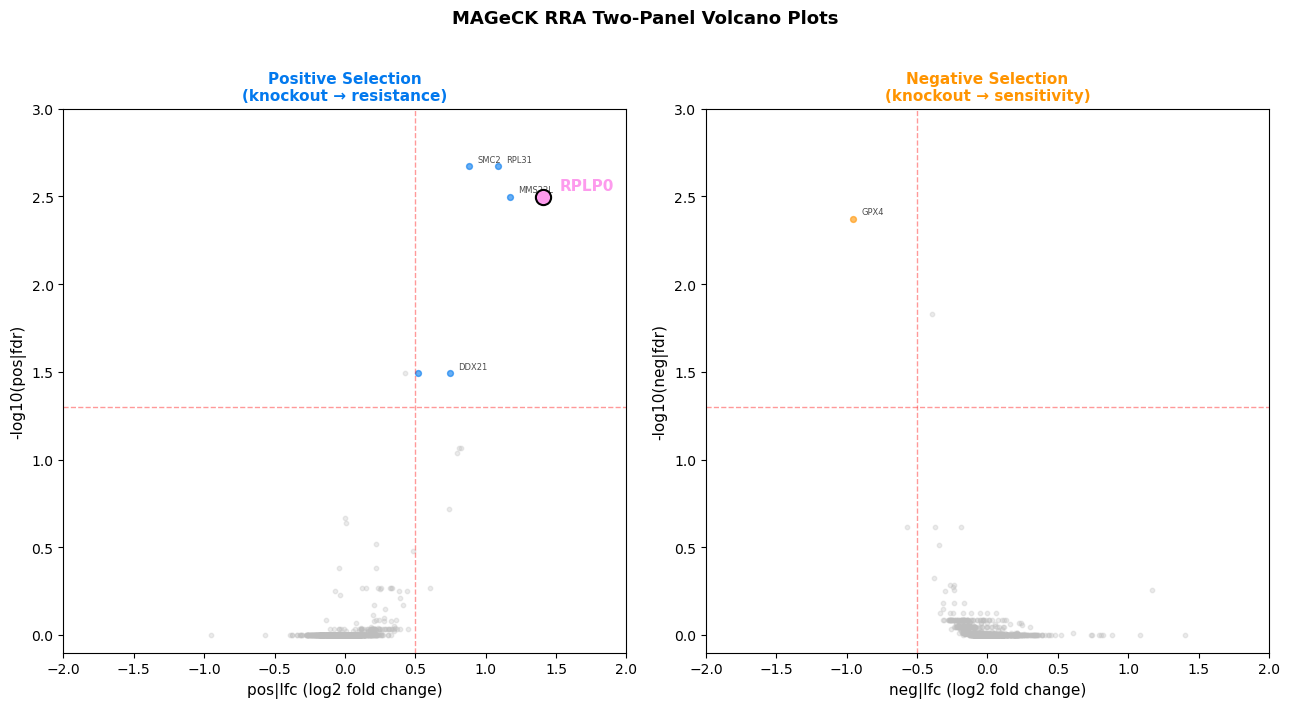

In [35]:

# ============================================================
# Cell 5: Two-panel volcano (pos and neg arms separately)
# ============================================================
# This is the approach used by several published HCC screens
# (e.g., Pan et al. 2022, Autophagy; Wei et al. 2019, Nat Commun)

fig, (ax_pos, ax_neg) = plt.subplots(1, 2, figsize=(13, 6.9))

# --- Positive selection panel ---
neg_log10_pos = -np.log10(df['pos_fdr'] + 1e-10)
sig_p = df['sig_pos']

ax_pos.scatter(df.loc[~sig_p, 'pos_lfc'], neg_log10_pos[~sig_p],
               c=COLOR_NS, s=10, alpha=0.3)
ax_pos.scatter(df.loc[sig_p, 'pos_lfc'], neg_log10_pos[sig_p],
               c=COLOR_POS, s=18, alpha=0.6)

# Highlight RPLP0
row = df[df['id'] == 'RPLP0']
if len(row) > 0:
    ax_pos.scatter(row['pos_lfc'], -np.log10(row['pos_fdr'] + 1e-10),
                   c=COLOR_HL, s=120, edgecolors='black', linewidth=1.5, zorder=5)
    ax_pos.annotate('RPLP0', (row['pos_lfc'].values[0], -np.log10(row['pos_fdr'].values[0] + 1e-10)),
                    textcoords="offset points", xytext=(12, 5),
                    fontsize=11, fontweight='bold', color=COLOR_HL)

# Auto-label top pos hits
for _, r in df[df['sig_pos']].nlargest(5, 'pos_lfc').iterrows():
    if r['id'] != 'RPLP0':
        ax_pos.annotate(r['id'], (r['pos_lfc'], -np.log10(r['pos_fdr'] + 1e-10)),
                        textcoords="offset points", xytext=(6, 3), fontsize=6, alpha=0.7)

ax_pos.axhline(-np.log10(FDR_THRESHOLD), color='red', linestyle='--', alpha=0.4, linewidth=1)
ax_pos.axvline(LFC_THRESHOLD, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax_pos.set_xlabel('pos|lfc (log2 fold change)', fontsize=11)
ax_pos.set_ylabel('-log10(pos|fdr)', fontsize=11)
ax_pos.set_xlim(-2, 2)
ax_pos.set_ylim(-0.1, 3)
ax_pos.set_title('Positive Selection\n(knockout → resistance)', fontsize=11, fontweight='bold', color=COLOR_POS)

# --- Negative selection panel ---
neg_log10_neg = -np.log10(df['neg_fdr'] + 1e-10)
sig_n = df['sig_neg']

ax_neg.scatter(df.loc[~sig_n, 'neg_lfc'], neg_log10_neg[~sig_n],
               c=COLOR_NS, s=10, alpha=0.3)
ax_neg.scatter(df.loc[sig_n, 'neg_lfc'], neg_log10_neg[sig_n],
               c=COLOR_NEG, s=18, alpha=0.6)

# # Highlight PHGDH
# row = df[df['id'] == 'PHGDH']
# if len(row) > 0:
#     ax_neg.scatter(row['neg_lfc'], -np.log10(row['neg_fdr'] + 1e-10),
#                    c=COLOR_PHGDH, s=120, edgecolors='black', linewidth=1.5, zorder=5)
#     ax_neg.annotate('PHGDH', (row['neg_lfc'].values[0], -np.log10(row['neg_fdr'].values[0] + 1e-10)),
#                     textcoords="offset points", xytext=(12, 5),
#                     fontsize=11, fontweight='bold', color=COLOR_PHGDH)

# Auto-label top neg hits
for _, r in df[df['sig_neg']].nsmallest(5, 'neg_lfc').iterrows():
    if r['id'] != 'PHGDH':
        ax_neg.annotate(r['id'], (r['neg_lfc'], -np.log10(r['neg_fdr'] + 1e-10)),
                        textcoords="offset points", xytext=(6, 3), fontsize=6, alpha=0.7)

ax_neg.axhline(-np.log10(FDR_THRESHOLD), color='red', linestyle='--', alpha=0.4, linewidth=1)
ax_neg.axvline(-LFC_THRESHOLD, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax_neg.set_xlabel('neg|lfc (log2 fold change)', fontsize=11)
ax_neg.set_ylabel('-log10(neg|fdr)', fontsize=11)
ax_neg.set_xlim(-2, 2)
ax_neg.set_ylim(-0.1, 3)
ax_neg.set_title('Negative Selection\n(knockout → sensitivity)', fontsize=11, fontweight='bold', color=COLOR_NEG)

plt.suptitle('MAGeCK RRA Two-Panel Volcano Plots', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/wkkongaa/data/notebooks/260612_miR_screen_reanalysis/_figure/figures/main_text/MAGeCK_two_panel_volcano_WT.pdf')
plt.show()


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo'

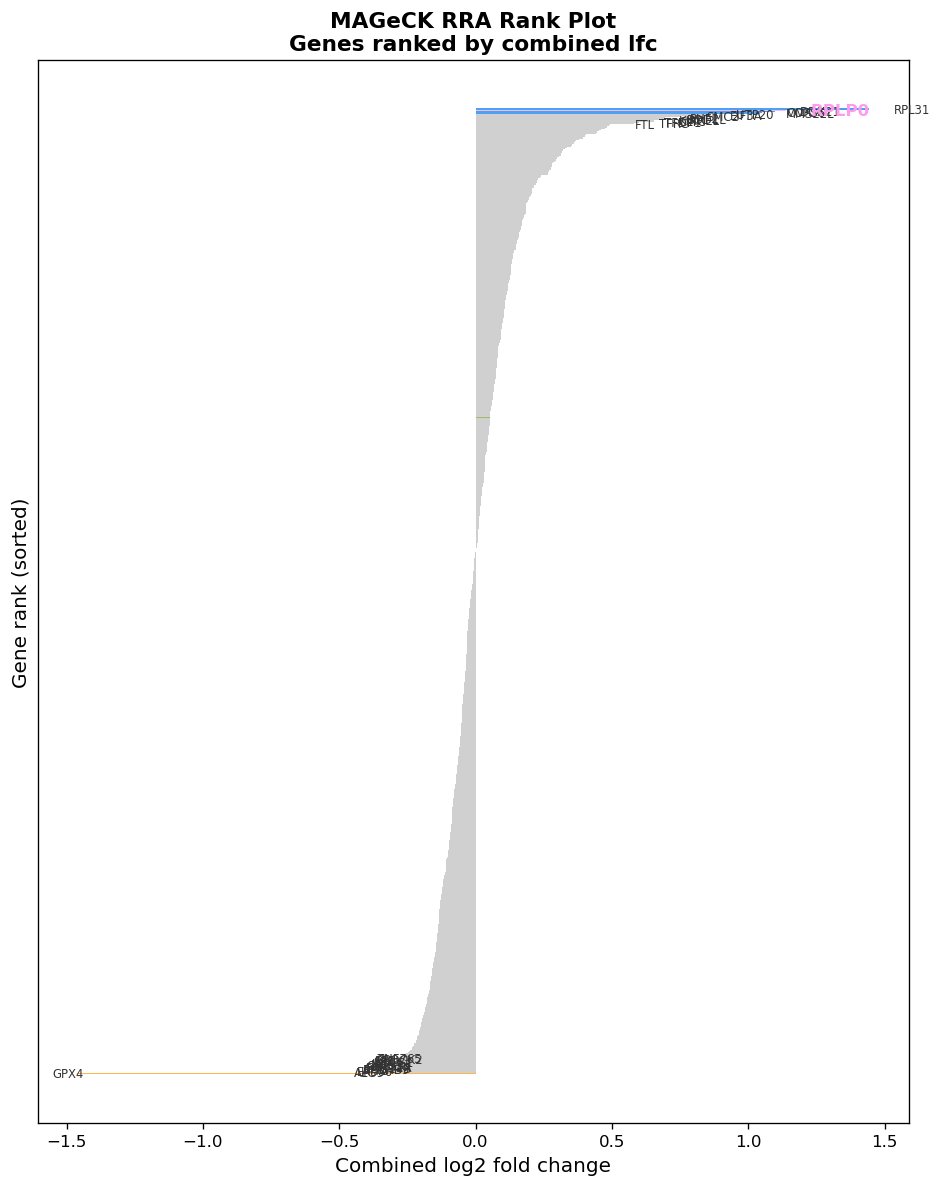

In [29]:

# ============================================================
# Cell 6: Rank plot (MAGeCKFlute RankView style)
# ============================================================
# Genes ranked by combined lfc; top and bottom hits labeled.
# Good for showing the full distribution and where your hits fall.

fig, ax = plt.subplots(figsize=(8, 10))

df_sorted = df.sort_values('combined_lfc').reset_index(drop=True)

colors = []
for _, row in df_sorted.iterrows():
    if row['id'] in HIGHLIGHT_GENES:
        colors.append(COLOR_HL if row['id'] == 'RPLP0' else COLOR_PHGDH)
    elif row['sig_combined_pos']:
        colors.append(COLOR_POS)
    elif row['sig_combined_neg']:
        colors.append(COLOR_NEG)
    else:
        colors.append(COLOR_NS)

ax.barh(range(len(df_sorted)), df_sorted['combined_lfc'], color=colors, height=1.0, alpha=0.7)
ax.set_yticks([])
ax.set_xlabel('Combined log2 fold change', fontsize=12)
ax.set_ylabel('Gene rank (sorted)', fontsize=12)
ax.set_title('MAGeCK RRA Rank Plot\nGenes ranked by combined lfc', fontsize=13, fontweight='bold')

# Label top and bottom N genes
top_n = 15
for i in list(range(top_n)) + list(range(len(df_sorted) - top_n, len(df_sorted))):
    gene = df_sorted.iloc[i]['id']
    lfc = df_sorted.iloc[i]['combined_lfc']
    is_highlight = gene in HIGHLIGHT_GENES
    ax.annotate(gene, (lfc, i),
                textcoords="offset points",
                xytext=(15 if lfc > 0 else -15, 0),
                fontsize=7 if not is_highlight else 10,
                va='center',
                color=COLOR_HL if gene == 'RPLP0' else (COLOR_PHGDH if gene == 'PHGDH' else '#333333'),
                fontweight='bold' if is_highlight else 'normal')

plt.tight_layout()
# plt.savefig('/mnt/results/viz_rank_plot.png', dpi=150, bbox_inches='tight')
# plt.savefig('/mnt/results/viz_rank_plot.svg', bbox_inches='tight')
plt.show()
# print("Saved: viz_rank_plot.png / .svg")


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo'

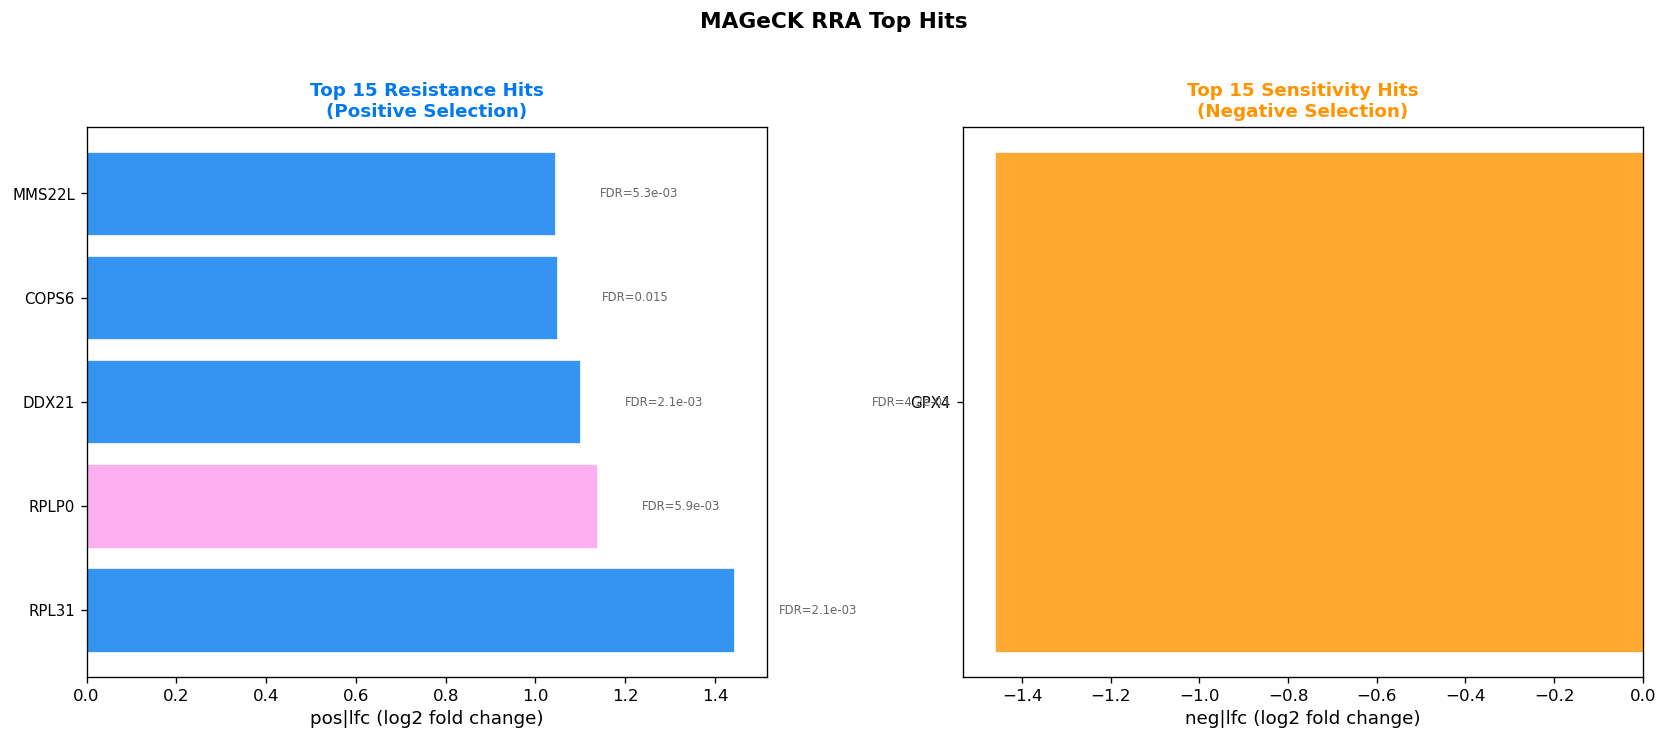

In [30]:

# ============================================================
# Cell 7: Top-hits bar plot (published HCC screen style)
# ============================================================
# Horizontal bar chart of top N hits from each arm.
# Similar to the style used in Wei et al. 2019 (Nat Commun)
# and Pan et al. 2022 (Autophagy) for highlighting specific hits.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

n_hits = 15

# --- Top positive selection hits (resistance) ---
top_pos = df[df['sig_pos']].nlargest(n_hits, 'pos_lfc').sort_values('pos_lfc')
colors_pos = [COLOR_HL if g == 'RPLP0' else COLOR_POS for g in top_pos['id']]
bars1 = ax1.barh(range(len(top_pos)), top_pos['pos_lfc'], color=colors_pos, alpha=0.8, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(top_pos)))
ax1.set_yticklabels(top_pos['id'], fontsize=9)
ax1.set_xlabel('pos|lfc (log2 fold change)', fontsize=11)
ax1.set_title(f'Top {n_hits} Resistance Hits\n(Positive Selection)', fontsize=11, fontweight='bold', color=COLOR_POS)
ax1.invert_yaxis()

# Add FDR annotations
for i, (_, row) in enumerate(top_pos.iterrows()):
    fdr_str = f"FDR={row['pos_fdr']:.1e}" if row['pos_fdr'] < 0.01 else f"FDR={row['pos_fdr']:.3f}"
    ax1.text(row['pos_lfc'] + 0.1, i, fdr_str, va='center', fontsize=7, color='#666666')

# --- Top negative selection hits (sensitivity) ---
top_neg = df[df['sig_neg']].nsmallest(n_hits, 'neg_lfc').sort_values('neg_lfc', ascending=False)
colors_neg = [COLOR_PHGDH if g == 'PHGDH' else COLOR_NEG for g in top_neg['id']]
bars2 = ax2.barh(range(len(top_neg)), top_neg['neg_lfc'], color=colors_neg, alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(top_neg)))
ax2.set_yticklabels(top_neg['id'], fontsize=9)
ax2.set_xlabel('neg|lfc (log2 fold change)', fontsize=11)
ax2.set_title(f'Top {n_hits} Sensitivity Hits\n(Negative Selection)', fontsize=11, fontweight='bold', color=COLOR_NEG)
ax2.invert_yaxis()

for i, (_, row) in enumerate(top_neg.iterrows()):
    fdr_str = f"FDR={row['neg_fdr']:.1e}" if row['neg_fdr'] < 0.01 else f"FDR={row['neg_fdr']:.3f}"
    ax2.text(row['neg_lfc'] - 0.1, i, fdr_str, va='center', ha='right', fontsize=7, color='#666666')

plt.suptitle('MAGeCK RRA Top Hits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('/mnt/results/viz_top_hits_bar.png', dpi=150, bbox_inches='tight')
# plt.savefig('/mnt/results/viz_top_hits_bar.svg', bbox_inches='tight')
plt.show()
# print("Saved: viz_top_hits_bar.png / .svg")


KeyError: 'sgRNA'

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Arimo'

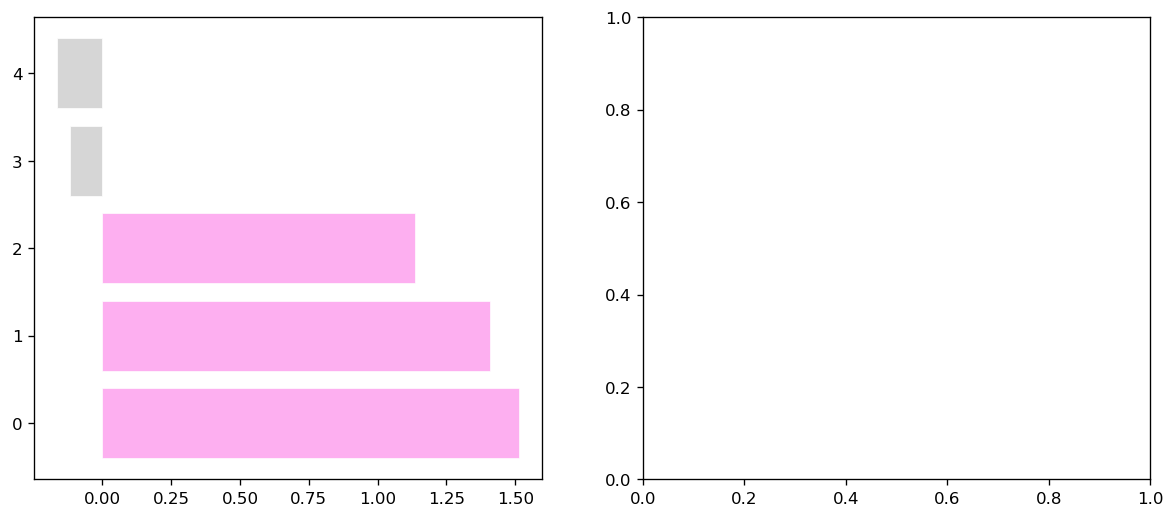

In [32]:

# ============================================================
# Cell 8: sgRNA-level view for specific genes
# ============================================================
# Shows individual sgRNA/shRNA fold changes for highlighted genes.
# Requires the sgRNA-level MAGeCK output (sgrna_summary.txt).


sgrna_df = pd.read_table("/home/wkkongaa/data/notebooks/260416_novaseq99/analysis/MAGeCK_output/599/599.sgrna_summary.txt")

fig, axes = plt.subplots(1, len(HIGHLIGHT_GENES), figsize=(12, 5))

for idx, gene in enumerate(HIGHLIGHT_GENES):
    ax = axes[idx]
    gene_sgrna = sgrna_df[sgrna_df['Gene'] == gene].sort_values('LFC', 
                                                                 ascending=(gene == 'PHGDH'))
    
    colors = [COLOR_HL if gene == 'RPLP0' else COLOR_PHGDH] * len(gene_sgrna)
    # Mark less effective shRNAs differently
    for i, row in enumerate(gene_sgrna.itertuples()):
        if abs(row.LFC) < abs(gene_sgrna['LFC'].mean()) * 0.5:
            colors[i] = '#CCCCCC'
    
    bars = ax.barh(range(len(gene_sgrna)), gene_sgrna['LFC'], color=colors, 
                   alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(gene_sgrna)))
    ax.set_yticklabels(gene_sgrna['sgRNA'], fontsize=9)
    ax.set_xlabel('log2 fold change', fontsize=10)
    ax.set_title(f'{gene}\nsgRNA-level view', fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    
    # Add mean line
    mean_LFC = gene_sgrna['LFC'].mean()
    ax.axvline(mean_LFC, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(mean_LFC, len(gene_sgrna) - 0.5, f'  mean={mean_LFC:.2f}', 
            fontsize=8, color='red', va='top')

plt.suptitle('sgRNA-Level Fold Changes for Highlighted Genes\n(gray = less effective shRNA)',
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('/mnt/results/viz_sgrna_level.png', dpi=150, bbox_inches='tight')
plt.savefig('/mnt/results/viz_sgrna_level.svg', bbox_inches='tight')
plt.show()
print("Saved: viz_sgrna_level.png / .svg")
print("\nNote: With real data, load sgrna_summary.txt from MAGeCK and filter by Gene column.")
